In [3]:
from google.colab import files
uploaded = files.upload()

Saving traffic_accidents.csv to traffic_accidents.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("traffic_accidents.csv")

df.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  object 
 1   traffic_control_device         209306 non-null  object 
 2   weather_condition              209306 non-null  object 
 3   lighting_condition             209306 non-null  object 
 4   first_crash_type               209306 non-null  object 
 5   trafficway_type                209306 non-null  object 
 6   alignment                      209306 non-null  object 
 7   roadway_surface_cond           209306 non-null  object 
 8   road_defect                    209306 non-null  object 
 9   crash_type                     209306 non-null  object 
 10  intersection_related_i         209306 non-null  object 
 11  damage                         209306 non-null  object 
 12  prim_contributory_cause       

In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
crash_date,0
traffic_control_device,0
weather_condition,0
lighting_condition,0
first_crash_type,0
trafficway_type,0
alignment,0
roadway_surface_cond,0
road_defect,0
crash_type,0


/tmp/ipykernel_3251/412276404.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


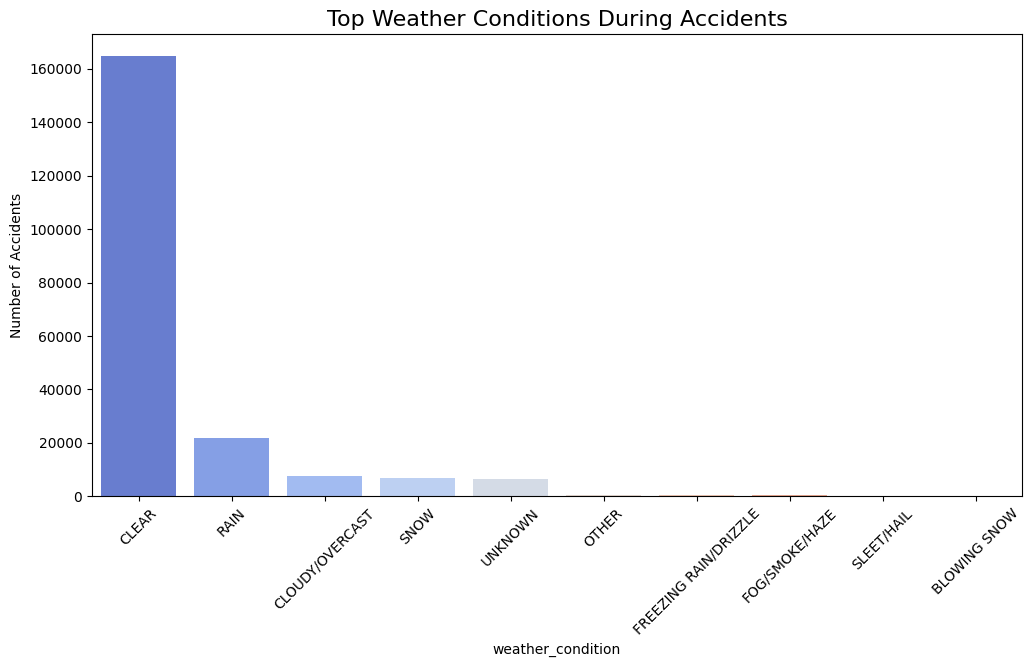

In [9]:
plt.figure(figsize=(12,6))

weather = df['weather_condition'].value_counts().head(10)

sns.barplot(
    x=weather.index,
    y=weather.values,
    palette='coolwarm'
)

plt.xticks(rotation=45)

plt.title("Top Weather Conditions During Accidents", fontsize=16)

plt.xlabel("weather_condition")
plt.ylabel("Number of Accidents")

plt.show()

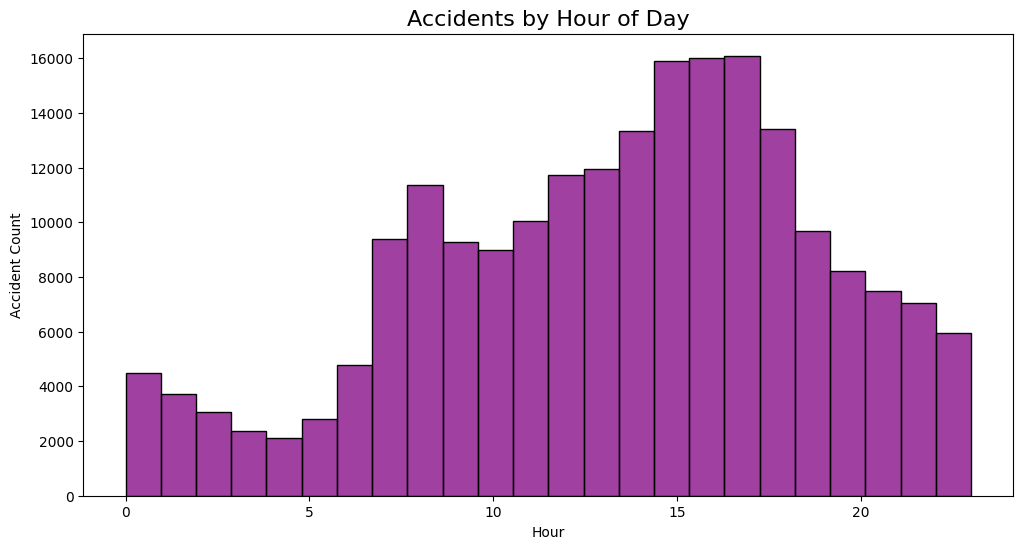

In [11]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['crash_hour'],
    bins=24,
    color='purple'
)

plt.title("Accidents by Hour of Day", fontsize=16)

plt.xlabel("Hour")
plt.ylabel("Accident Count")

plt.show()

/tmp/ipykernel_3251/1512834251.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


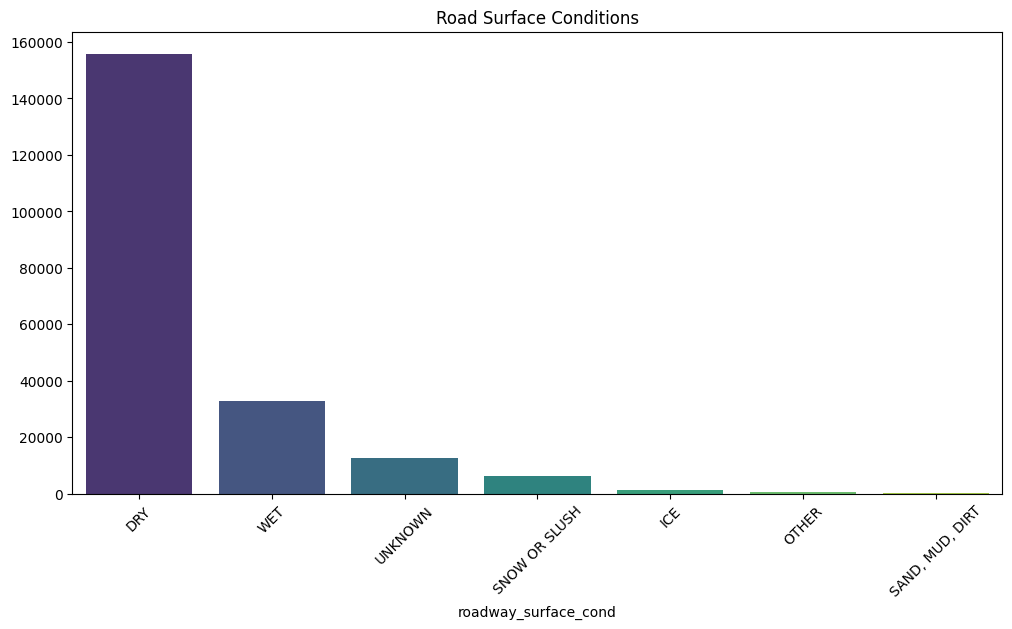

In [13]:
plt.figure(figsize=(12,6))

road = df['roadway_surface_cond'].value_counts().head(10)

sns.barplot(
    x=road.index,
    y=road.values,
    palette='viridis'
)

plt.xticks(rotation=45)

plt.title("Road Surface Conditions")

plt.show()

/tmp/ipykernel_3251/656411071.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


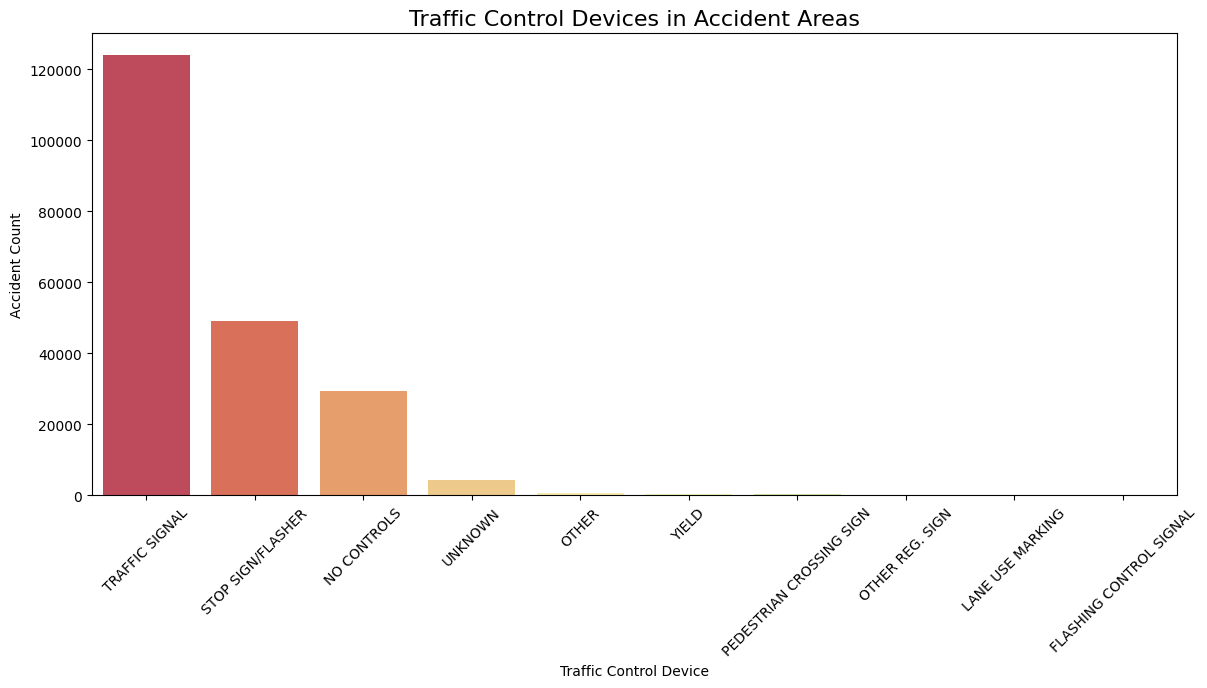

In [15]:
plt.figure(figsize=(14,6))

traffic = df['traffic_control_device'].value_counts().head(10)

sns.barplot(
    x=traffic.index,
    y=traffic.values,
    palette='Spectral'
)

plt.xticks(rotation=45)

plt.title("Traffic Control Devices in Accident Areas", fontsize=16)

plt.xlabel("Traffic Control Device")
plt.ylabel("Accident Count")

plt.show()

/tmp/ipykernel_3251/795904207.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


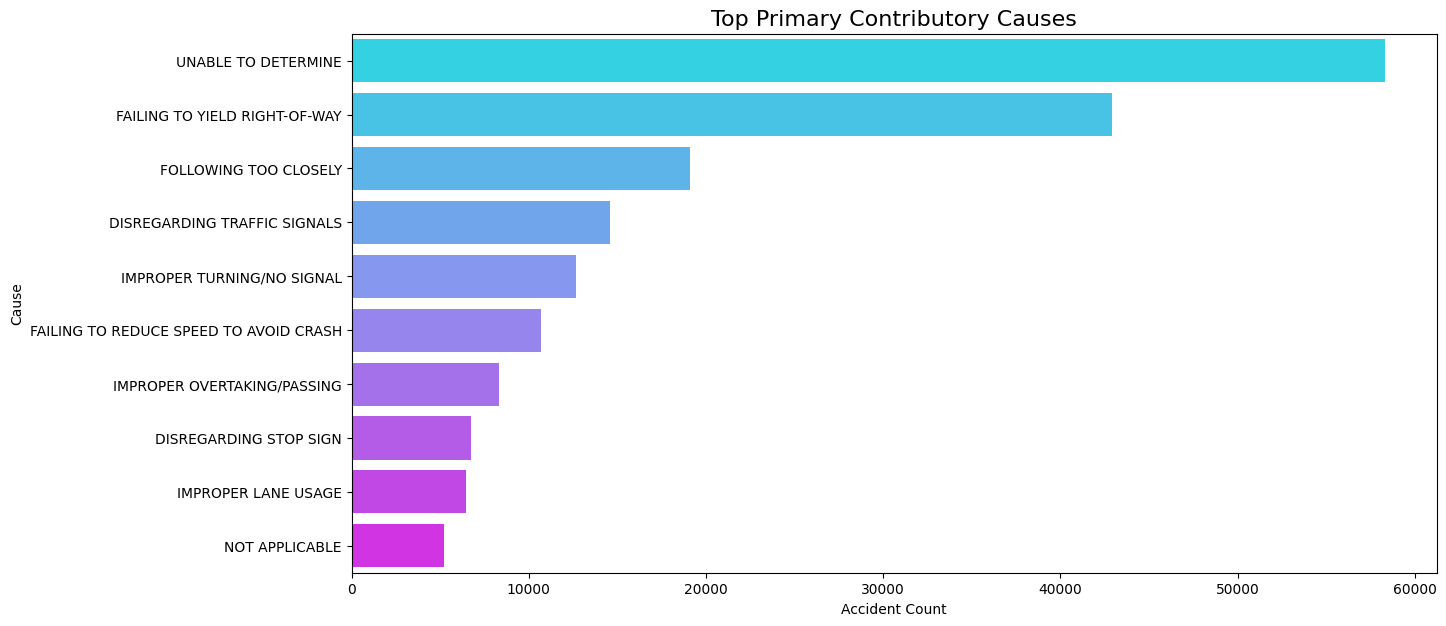

In [16]:
plt.figure(figsize=(14,7))

cause = df['prim_contributory_cause'].value_counts().head(10)

sns.barplot(
    x=cause.values,
    y=cause.index,
    palette='cool'
)

plt.title("Top Primary Contributory Causes", fontsize=16)

plt.xlabel("Accident Count")
plt.ylabel("Cause")

plt.show()

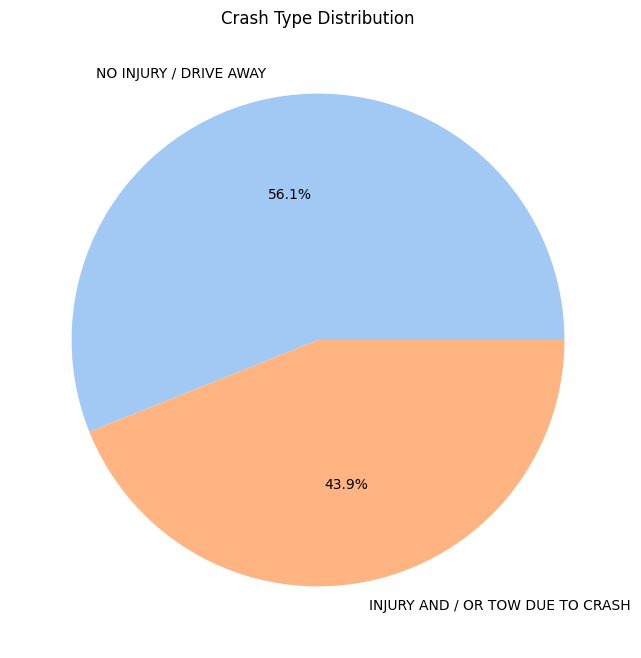

In [17]:
plt.figure(figsize=(8,8))

crash = df['crash_type'].value_counts().head(5)

plt.pie(
    crash.values,
    labels=crash.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel')
)

plt.title("Crash Type Distribution")

plt.show()

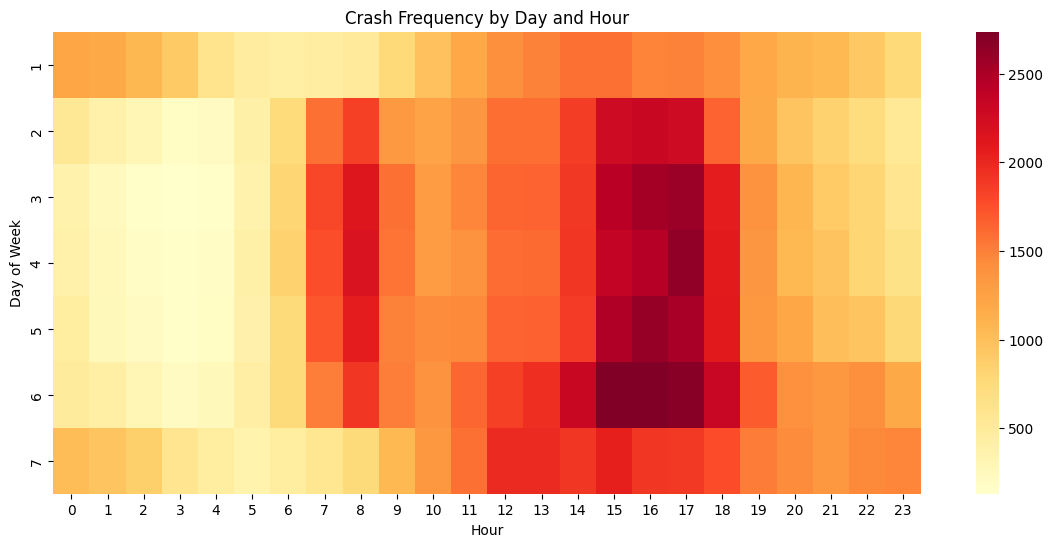

In [18]:
pivot = pd.crosstab(
    df['crash_day_of_week'],
    df['crash_hour']
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap='YlOrRd'
)

plt.title("Crash Frequency by Day and Hour")

plt.xlabel("Hour")
plt.ylabel("Day of Week")

plt.show()

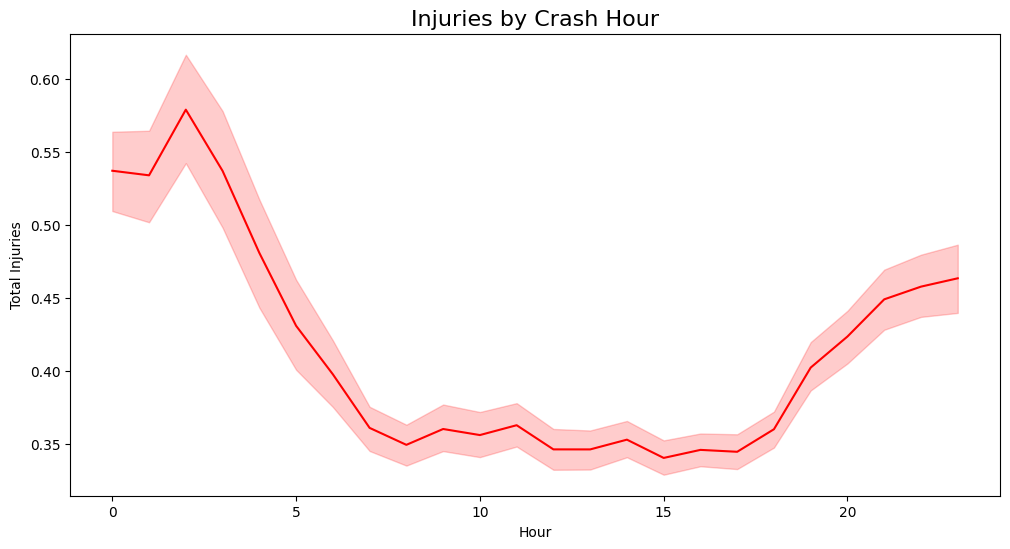

In [19]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x='crash_hour',
    y='injuries_total',
    data=df,
    color='red'
)

plt.title("Injuries by Crash Hour", fontsize=16)

plt.xlabel("Hour")
plt.ylabel("Total Injuries")

plt.show()

/tmp/ipykernel_3251/1183482251.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


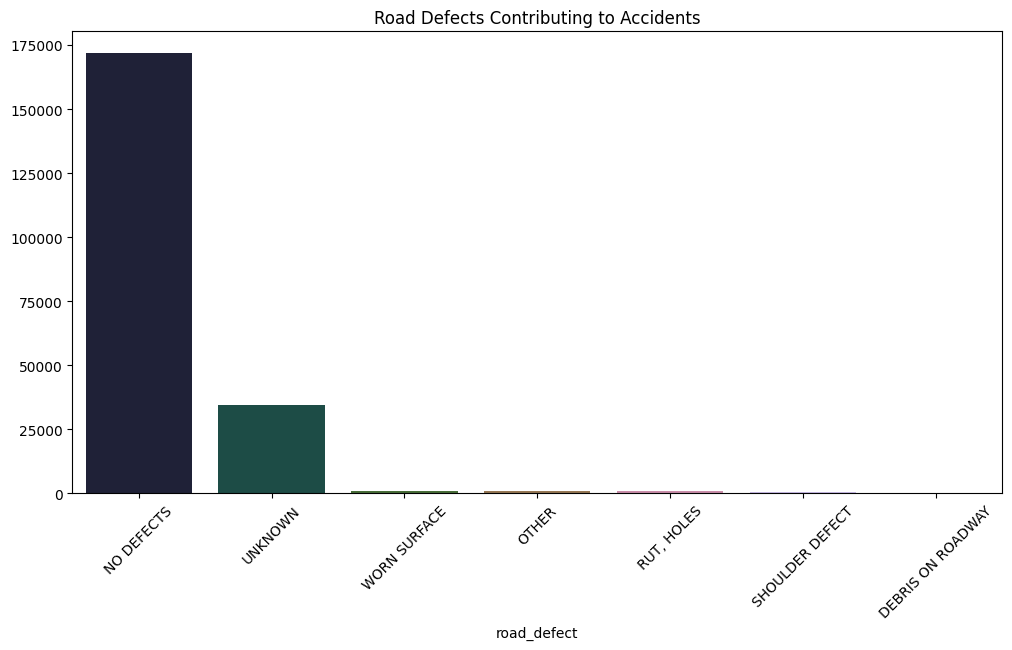

In [20]:
plt.figure(figsize=(12,6))

defect = df['road_defect'].value_counts().head(10)

sns.barplot(
    x=defect.index,
    y=defect.values,
    palette='cubehelix'
)

plt.xticks(rotation=45)

plt.title("Road Defects Contributing to Accidents")

plt.show()

/tmp/ipykernel_3251/1284897210.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


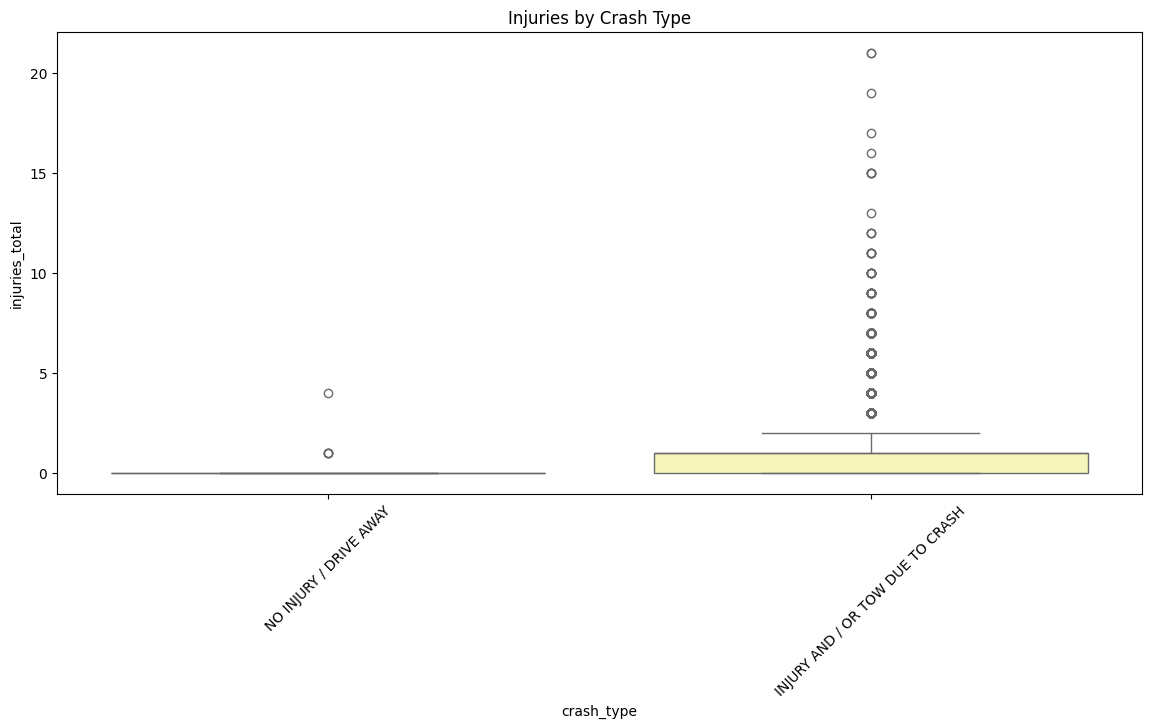

In [21]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x='crash_type',
    y='injuries_total',
    data=df,
    palette='Set3'
)

plt.xticks(rotation=45)

plt.title("Injuries by Crash Type")

plt.show()

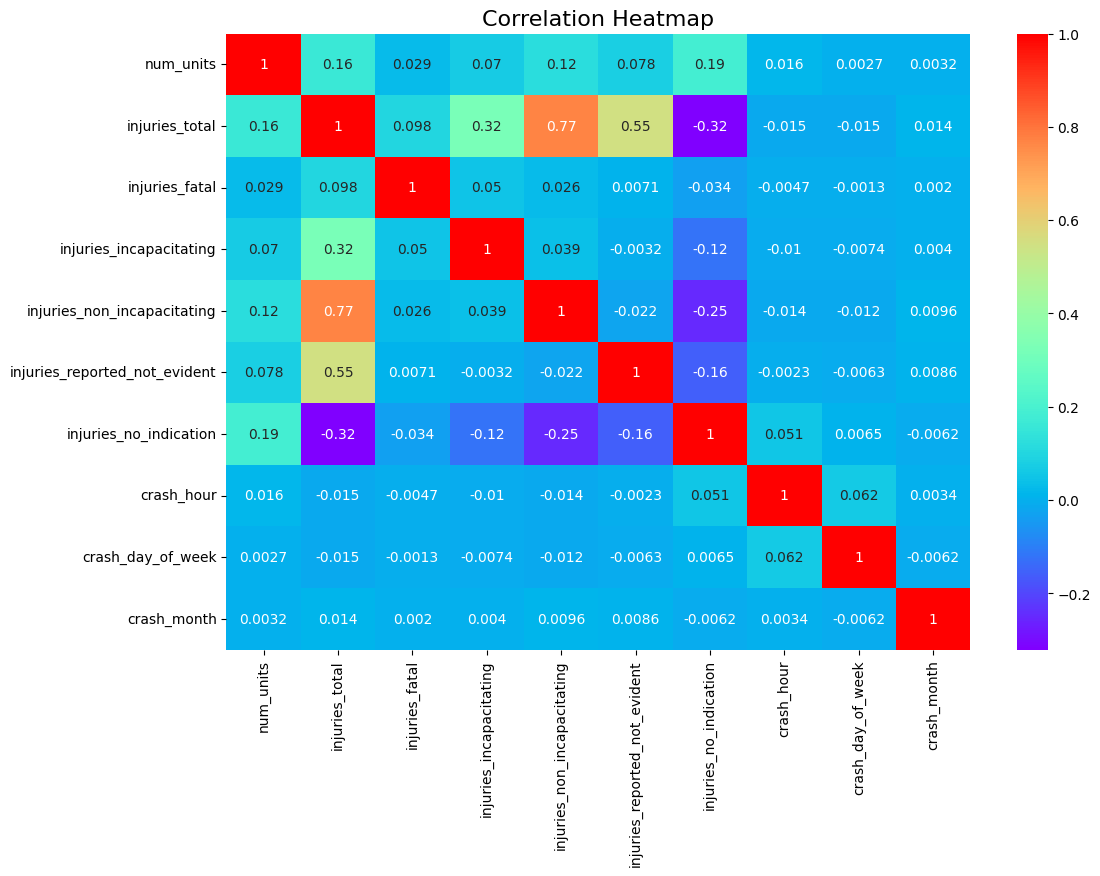

In [22]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='rainbow'
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

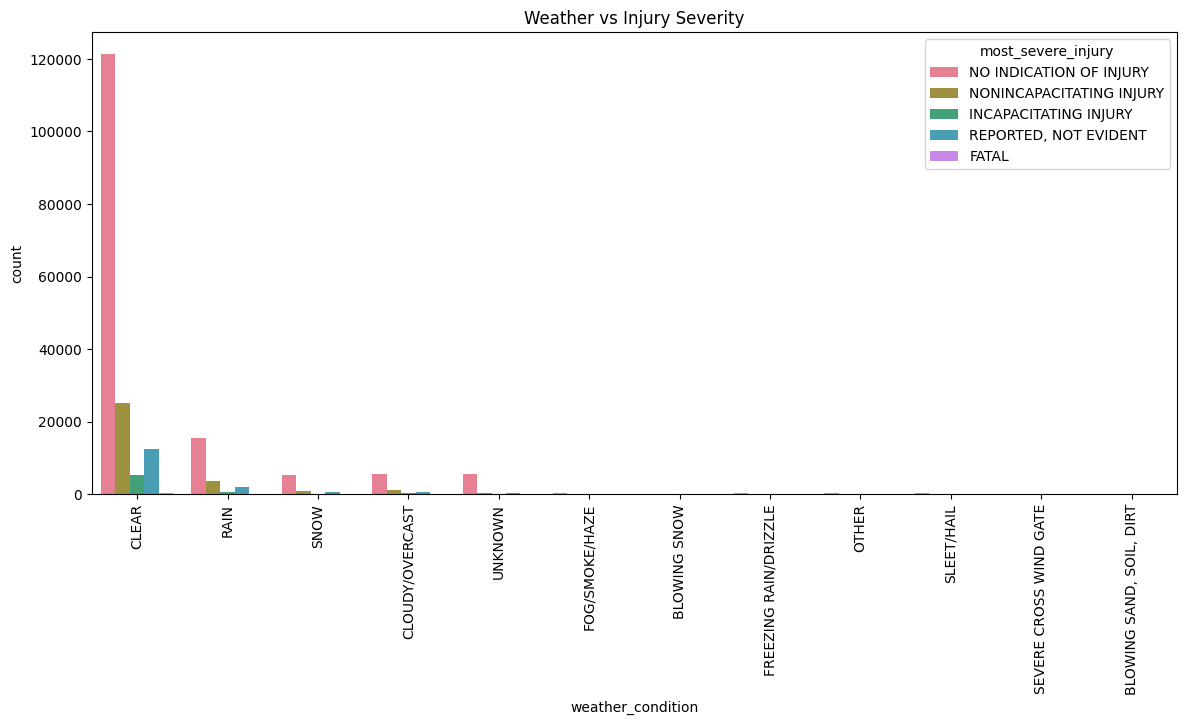

In [23]:
plt.figure(figsize=(14,6))

sns.countplot(
    x='weather_condition',
    hue='most_severe_injury',
    data=df,
    palette='husl'
)

plt.xticks(rotation=90)

plt.title("Weather vs Injury Severity")

plt.show()

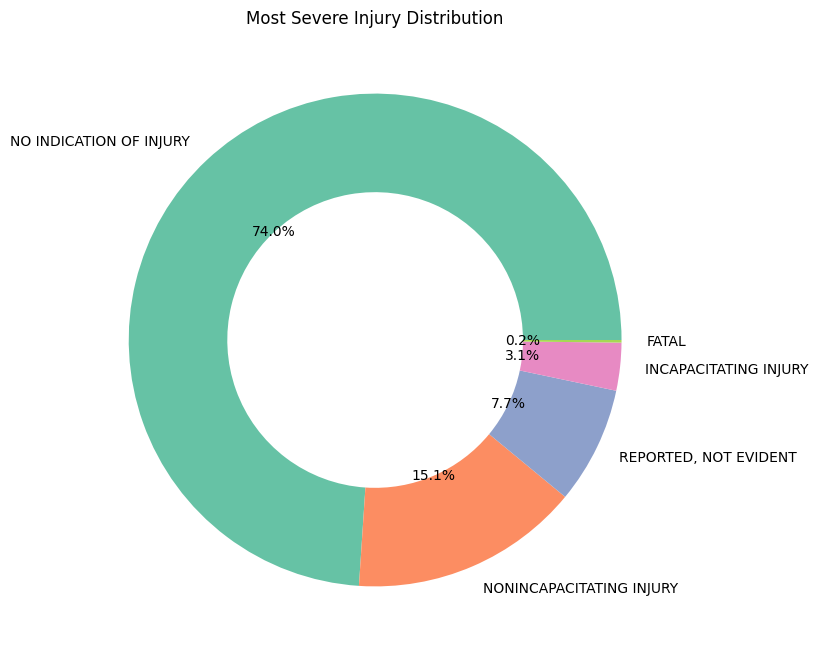

In [24]:
injury = df['most_severe_injury'].value_counts().head(5)

plt.figure(figsize=(8,8))

plt.pie(
    injury.values,
    labels=injury.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2'),
    wedgeprops=dict(width=0.4)
)

plt.title("Most Severe Injury Distribution")

plt.show()

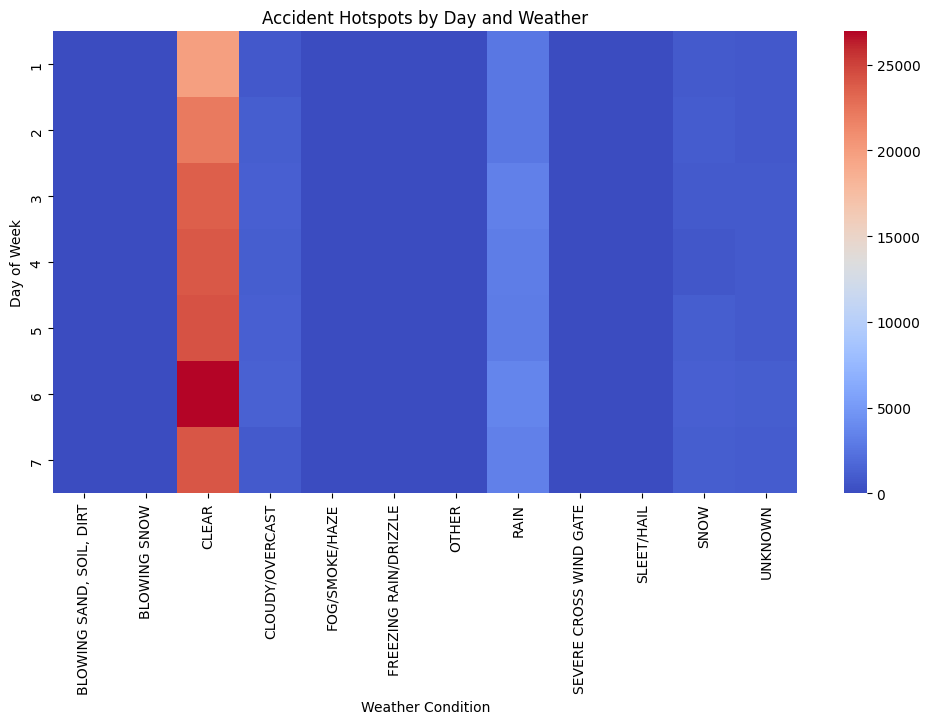

In [25]:
plt.figure(figsize=(12,6))

pivot = pd.crosstab(
    df['crash_day_of_week'],
    df['weather_condition']
)

sns.heatmap(
    pivot,
    cmap='coolwarm'
)

plt.title("Accident Hotspots by Day and Weather")

plt.xlabel("Weather Condition")
plt.ylabel("Day of Week")

plt.show()